# Storytelling with Data: เหตุความรุนแรงในครอบครัว

---
> **เป้าหมาย:** ฝึกฝนการเล่าเรื่องราวอย่างเป็นระบบผ่านกระบวนการการทำตั้งแต่
> 1. Exploratory Data Analysis (EDA)
> 2. Clean Data
> 3. Find Insight
> 4. Create Graph

> ปล. ตอนแรก Colab ของผมใช้อีเมลของออฟฟิศ ตอนนี้ย้าย Colab มาเป็นอีเมลที่สมัครโครงการเรียบร้อยครับ
---
> **Colab URL:** https://colab.research.google.com/drive/16us5MlX7BSY4bSAwSuuN-dzL4VSGq-2w?usp=sharing
>
> **Dataset:** https://www.thackle.or.th/api/v1/file/download/datatset/84
---

>| ขั้นตอน | หัวข้อ |
>|--------|------|
>| 01 | ติดตั้งไลบรารีและโหลดไลบรารี |
>| 02 | โหลดข้อมูลทั้งสามไฟล์เข้า Google Colab |
>| 03 | การทำความสะอาดข้อมูล การตรวจสอบ และการสำรวจข้อมูลเบื้องต้น |
>| 04 | เริ่มค้นคว้าตีความข้อมูลและสำรวจทั้งสามไฟล์ |
>| 05 | การวิเคราะห์การกระจายตัวของอายุระหว่างผู้ก่อความรุนแรง VS. ผู้ถูกกระทำความรุนแรงในครอบครัว |
>| 06 | การวิเคราะห์การกระจายตัวของอายุและเพศระหว่างผู้ก่อความรุนแรง VS. ผู้ถูกกระทำความรุนแรงในครอบครัว |
>| 07 | การวิเคราะห์สัดส่วนเพศและความรุนแรงในครอบครัว |
>| 08 | แต่ละคนมีเส้นทางสู่ความรุนแรงที่ต่างกัน |
>| 09 | ภาพรวมความเสี่ยงจากทั้งสองบทบาท |
>| 10 | ปัจจัยเร่งความรุนแรงครอบครัวคนไทย
---

> **ข้อมูล:** ชุดข้อมูลเหตุความรุนแรงในครอบครัว  
> **แหล่งที่มา:** Big Data Institute

## ติดตั้งไลบรารีและโหลดไลบรารี

In [ ]:
## ติดตั้งและโหลดไลบรารีที่จำเป็นก่อนเริ่มต้นวิเคราะห์ข้อมูล
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
from matplotlib import legend
import seaborn as sns
import pandas as pd
import numpy as np
import os

## ซ่อน warning ที่ไม่จำเป็น
import warnings
warnings.filterwarnings('ignore')

## ดาวน์โหลด Google Font (Sarabun) สำหรับภาษาไทย
!wget -q https://github.com/google/fonts/raw/main/ofl/sarabun/Sarabun-Regular.ttf

## ลงทะเบียนฟอนต์กับ Matplotlib
font_path = './Sarabun-Regular.ttf'
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)

## ตั้งค่า Font ให้เป็นค่าเริ่มต้น (มีผลกับทั้ง Matplotlib และ Seaborn)
plt.rcParams['font.family'] = prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

## ตั้งค่าธีม Seaborn เบื้องต้น
sns.set_theme(style="whitegrid", font=prop.get_name())

print(f"✅นำเข้าไลบรารีและติดตั้งฟอนต์ {prop.get_name()} เรียบร้อย")

✅นำเข้าไลบรารีและติดตั้งฟอนต์ Sarabun เรียบร้อย


## โหลดข้อมูลทั้งสามไฟล์เข้า Google Colab

In [ ]:
## อัปโหลดข้อมูลทั้ง 3 ไฟล์จากคอมพิวเตอร์/โน๊ตบุ๊กของตัวเอง
## ข้อมูลที่หนึ่งจะตั้งชื่อตัวแปรเป็น DVIR ย่อจาก Domestic Violence Incident Report
## ข้อมูลที่สองจะตั้งชื่อตัวแปรเป็น DVPD ย่อจาก Domestic Violence Perpetrator Data
## ข้อมูลที่สองจะตั้งชื่อตัวแปรเป็น DVPD ย่อจาก Domestic Violence Perpetrator Data
dvir_path = '/content/01_ข้อมูลการแจ้งเหตุความรุนแรงในครอบครัว.csv'
dvpd_path = '/content/02_ข้อมูลผู้กระทำความรุนแรงในครอบครัว.csv'
dvvd_path = '/content/03_ข้อมูลผู้ถูกกระทำความรุนแรงในครอบครัว.csv'


try:
## ข้อดีของ utf-8-sig สามารถช่วยแก้ปัญหาตัวอักษรต่าวดาวจากไฟล์ excel หรือ csv
## ซึ่งเมื่อใช้ uft-8sig คุณจะพบข้อมูลที่สะอาดนั้นเอง
    one_dvir_df = pd.read_csv(dvir_path, encoding = 'utf-8-sig')
    two_dvpd_df = pd.read_csv(dvpd_path, encoding = 'utf-8-sig')
    three_dvvd_df = pd.read_csv(dvvd_path, encoding = 'utf-8-sig')

    lend = '=' * 124

    print(lend)
    print('✅ตัวอย่างข้อมูลชุดที่หนึ่ง :')
    display(one_dvir_df.head(3))
    print(lend)
    print('✅ตัวอย่างข้อมูลชุดที่สอง :')
    display(two_dvpd_df.head(3))
    print(lend)
    print('✅ตัวอย่างข้อมูลชุดที่สาม :')
    display(three_dvvd_df.head(3))
    print(lend)

except: print('อย่าลืมเช็กไฟล์อีกครั้ง! คุณลืมอัปโหลดหรือเปล่า')

✅ตัวอย่างข้อมูลชุดที่หนึ่ง :


,Regional,Province,District,Sub-District,Derivation,Source,Source Type,Other Source Type,Channel,Period,Locale
0,ภาคกลาง,กรุงเทพมหานคร,เขตหนองจอก,ลำผักชี,VCIS (Incident ถูกสร้างจากระบบ VCIS),หน่วยงาน,สายด่วน 1300,ไม่ระบุ,หนังสือราชการหรือหนังสือจากหน่วยงาน,12:01 – 18:00,สถานที่ส่วนบุคคล
1,ภาคกลาง,กรุงเทพมหานคร,เขตบางแค,บางแค,VCIS (Incident ถูกสร้างจากระบบ VCIS),หน่วยงาน,สายด่วน 1300,ไม่ระบุ,หนังสือราชการหรือหนังสือจากหน่วยงาน,12:01 – 18:00,สถานที่ส่วนบุคคล
2,ภาคกลาง,กรุงเทพมหานคร,เขตทวีวัฒนา,ศาลาธรรมสพน์,VCIS (Incident ถูกสร้างจากระบบ VCIS),หน่วยงาน,สายด่วน 1300,ไม่ระบุ,ระบบ,18:01 – 00:00,สถานที่ส่วนบุคคล


✅ตัวอย่างข้อมูลชุดที่สอง :


,Regional,Province,District,Sub-District,Gender,Age,Age Range,Relation,Mariage Registration,Alcohol,Drug,Authoritative,Rage,Jealous,Divorce,Health Problem,Mental Problem,Gambling Addict,Economics Stress
0,ภาคกลาง,กรุงเทพมหานคร,เขตหนองจอก,ลำผักชี,หญิง,61,วัยสูงอายุ 60 ปีขึ้นไป,โสด,ไม่ระบุ,ไม่,ไม่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่
1,ภาคกลาง,กรุงเทพมหานคร,เขตบางแค,บางแค,หญิง,26,วัยผู้ใหญ่ตอนต้น 19 - 35 ปี,โสด,ไม่ระบุ,ไม่,ไม่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่
2,ภาคกลาง,กรุงเทพมหานคร,เขตทวีวัฒนา,ศาลาธรรมสพน์,หญิง,55,วัยกลางคน 36 - 59 ปี,โสด,ไม่ระบุ,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่,ใช่,ไม่,ไม่


✅ตัวอย่างข้อมูลชุดที่สาม :


,Regional,Province,District,Sub-District,Gender,Age,Age Range,Relation,Mariage Registration,Alcohol,Drug,Authoritative,Rage,Jealous,Divorce,Health Problem,Mental Problem,Gambling Addict,Economics Stress,Relation Type
0,ภาคกลาง,กรุงเทพมหานคร,เขตหนองจอก,ลำผักชี,หญิง,18,วัยรุ่น 13 - 18 ปี,โสด,ไม่ระบุ,ไม่,ไม่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่,ยาย
1,ภาคกลาง,กรุงเทพมหานคร,เขตบางแค,บางแค,หญิง,36,วัยกลางคน 36 - 59 ปี,โสด,ไม่ระบุ,ไม่,ไม่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่,พี่น้อง/ลูกพี่ลูกน้อง
2,ภาคกลาง,กรุงเทพมหานคร,เขตทวีวัฒนา,ศาลาธรรมสพน์,ชาย,78,วัยสูงอายุ 60 ปีขึ้นไป,แยกกันอยู่,ยังไม่ได้จดทะเบียนหย่า,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่,ใช่,ไม่,ไม่,บุตร


## การทำความสะอาดข้อมูล การตรวจสอบ และการสำรวจข้อมูลเบื้องต้น

In [ ]:
## ตรวจสอบจำนวนคอลัมน์และจำนวนแถวของข้อมูลทั้งสามชุด

lend = '=' * 124

print(lend)
print('✅ข้อมูลการแจ้งเหตุความรุนแรงในครอบครัว')
print(f'จำนวนแถว: {one_dvir_df.shape[0]} | จำนวนคอลัมน์: {one_dvir_df.shape[1]}')

print(lend)
print('✅ข้อมูลผู้กระทำความรุนแรงในครอบครัว')
print(f'จำนวนแถว: {two_dvpd_df.shape[0]} | จำนวนคอลัมน์: {two_dvpd_df.shape[1]}')

print(lend)
print('✅ข้อมูลผู้ถูกกระทำความรุนแรงในครอบครัว')
print(f'จำนวนแถว: {three_dvvd_df.shape[0]} | จำนวนคอลัมน์: {three_dvvd_df.shape[1]}')
print(lend)

✅ข้อมูลการแจ้งเหตุความรุนแรงในครอบครัว
จำนวนแถว: 877 | จำนวนคอลัมน์: 11
✅ข้อมูลผู้กระทำความรุนแรงในครอบครัว
จำนวนแถว: 564 | จำนวนคอลัมน์: 19
✅ข้อมูลผู้ถูกกระทำความรุนแรงในครอบครัว
จำนวนแถว: 597 | จำนวนคอลัมน์: 20


In [ ]:
## ตรวจสอบข้อมูลที่ซ้ำด้วยข้อมูลทั้งหมด
print(f'✅เช็กจำนวนแถวที่ซ้ำกันของข้อมูลการแจ้งเหตุความรุนแรงในครอบครัว: {one_dvir_df.duplicated(keep = False).sum()} แถว')
print(f'✅เช็กจำนวนแถวที่ซ้ำกันของข้อมูลผู้กระทำความรุนแรงในครอบครัว: {two_dvpd_df.duplicated(keep = False).sum()} แถว')
print(f'✅เช็กจำนวนแถวที่ซ้ำกันของข้อมูลผู้ถูกกระทำความรุนแรงในครอบครัว: {three_dvvd_df.duplicated(keep = False).sum()} แถว')

✅เช็กจำนวนแถวที่ซ้ำกันของข้อมูลการแจ้งเหตุความรุนแรงในครอบครัว: 31 แถว
✅เช็กจำนวนแถวที่ซ้ำกันของข้อมูลผู้กระทำความรุนแรงในครอบครัว: 22 แถว
✅เช็กจำนวนแถวที่ซ้ำกันของข้อมูลผู้ถูกกระทำความรุนแรงในครอบครัว: 20 แถว


In [ ]:
## แสดงแถวที่ซ้ำกันของข้อมูลการแจ้งเหตุความรุนแรงในครอบครัว
one_duplicate_rows = one_dvir_df[one_dvir_df.duplicated(keep = False)]

## แสดงแถวที่ซ้ำกันของข้อมูลผู้กระทำความรุนแรงในครอบครัว
two_duplicate_rows = two_dvpd_df[two_dvpd_df.duplicated(keep = False)]

## แสดงแถวที่ซ้ำกันของข้อมูลผู้ถูกกระทำความรุนแรงในครอบครัว
three_duplicate_rows = three_dvvd_df[three_dvvd_df.duplicated(keep = False)]

lend = '=' * 124

print(lend)
print(f'✅พบแถวที่ซ้ำกันทั้งหมด {len(one_duplicate_rows)} แถว:')
display(one_duplicate_rows.head(3))

print(lend)
print(f'✅พบแถวที่ซ้ำกันทั้งหมด {len(two_duplicate_rows)} แถว:')
display(two_duplicate_rows.head(3))

print(lend)
print(f'✅พบแถวที่ซ้ำกันทั้งหมด {len(three_duplicate_rows)} แถว:')
display(three_duplicate_rows.head(3))
print(lend)

✅พบแถวที่ซ้ำกันทั้งหมด 31 แถว:


,Regional,Province,District,Sub-District,Derivation,Source,Source Type,Other Source Type,Channel,Period,Locale
13,ภาคกลาง,กรุงเทพมหานคร,เขตทุ่งครุ,บางมด,VCIS (Incident ถูกสร้างจากระบบ VCIS),หน่วยงาน,สายด่วน 1300,ไม่ระบุ,ระบบ,06:01 – 12:00,สถานที่ส่วนบุคคล
50,ภาคกลาง,กรุงเทพมหานคร,เขตวัฒนา,คลองตันเหนือ,VCIS (Incident ถูกสร้างจากระบบ VCIS),หน่วยงาน,สายด่วน 1300,ไม่ระบุ,โทรศัพท์,18:01 – 00:00,สถานที่ส่วนบุคคล
62,ภาคกลาง,กรุงเทพมหานคร,เขตวัฒนา,คลองตันเหนือ,VCIS (Incident ถูกสร้างจากระบบ VCIS),หน่วยงาน,สายด่วน 1300,ไม่ระบุ,โทรศัพท์,18:01 – 00:00,สถานที่ส่วนบุคคล


✅พบแถวที่ซ้ำกันทั้งหมด 22 แถว:


,Regional,Province,District,Sub-District,Gender,Age,Age Range,Relation,Mariage Registration,Alcohol,Drug,Authoritative,Rage,Jealous,Divorce,Health Problem,Mental Problem,Gambling Addict,Economics Stress
10,ภาคกลาง,กรุงเทพมหานคร,เขตทุ่งครุ,บางมด,ชาย,22,วัยผู้ใหญ่ตอนต้น 19 - 35 ปี,แยกกันอยู่,ยังไม่ได้จดทะเบียนหย่า,ไม่,ไม่,ไม่,ไม่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่
14,ภาคกลาง,กรุงเทพมหานคร,เขตภาษีเจริญ,บางหว้า,ชาย,48,วัยกลางคน 36 - 59 ปี,สมรส,ยังไม่ได้จดทะเบียนสมรส,ใช่,ไม่,ใช่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่
28,ภาคกลาง,กรุงเทพมหานคร,เขตภาษีเจริญ,บางหว้า,ชาย,48,วัยกลางคน 36 - 59 ปี,สมรส,ยังไม่ได้จดทะเบียนสมรส,ใช่,ไม่,ใช่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่


✅พบแถวที่ซ้ำกันทั้งหมด 20 แถว:


,Regional,Province,District,Sub-District,Gender,Age,Age Range,Relation,Mariage Registration,Alcohol,Drug,Authoritative,Rage,Jealous,Divorce,Health Problem,Mental Problem,Gambling Addict,Economics Stress,Relation Type
10,ภาคกลาง,กรุงเทพมหานคร,เขตทุ่งครุ,บางมด,หญิง,32,วัยผู้ใหญ่ตอนต้น 19 - 35 ปี,แยกกันอยู่,ยังไม่ได้จดทะเบียนหย่า,ไม่,ไม่,ไม่,ไม่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่,"คู่ชีวิต,อดีตสามี"
14,ภาคกลาง,กรุงเทพมหานคร,เขตภาษีเจริญ,บางหว้า,หญิง,54,วัยกลางคน 36 - 59 ปี,สมรส,ยังไม่ได้จดทะเบียนสมรส,ใช่,ไม่,ใช่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่,"คู่ชีวิต,สามี"
29,ภาคกลาง,กรุงเทพมหานคร,เขตภาษีเจริญ,บางหว้า,หญิง,54,วัยกลางคน 36 - 59 ปี,สมรส,ยังไม่ได้จดทะเบียนสมรส,ใช่,ไม่,ใช่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่,"คู่ชีวิต,สามี"


In [ ]:
## หลังจากนั้นทำการลบข้อมูลที่มีค่าซ้ำกัน
one_dvir_df = one_dvir_df.drop_duplicates().reset_index(drop= True)
two_dvpd_df = two_dvpd_df.drop_duplicates().reset_index(drop = True)
three_dvvd_df = three_dvvd_df.drop_duplicates().reset_index(drop = True)

## อย่าลืมลบค่า whitespace ด้วยเด็ดขาดนะจ๊ะ
for df in [one_dvir_df, two_dvpd_df, three_dvvd_df]:
  for col in df.select_dtypes(include = 'object').columns:
    df[col] = df[col].str.strip()

## แปลงคอลัมน์ที่มีค่า "ใช่/ไม่ใช่" เป็น boolean
boolean_cols = ['Alcohol', 'Drug', 'Authoritative', 'Rage', 'Jealous', 'Divorce', 'Health Problem', 'Mental Problem', 'Gambling Addict', 'Economics Stress']

for df in [two_dvpd_df, three_dvvd_df]:
  for col in boolean_cols:
    df[col] = df[col].map({'ใช่': True, 'ไม่': False})


lend = '=' * 124

print(lend)
print('✅ลบข้อมูลที่มีค่าซ้ำกันเรียบร้อยครับ')
print('✅ลบค่า whitespace ส่วนที่เป็น string/object เรียบร้อยครับ')
print('✅แปลงค่า "ใช่/ไม่ใช่" boolean เรียบร้อยครับ')

print(lend)

## รีเช็กค่าซ้ำอีกรอบ
print(f'✅ข้อมูลการแจ้งเหตุความรุนแรงเหลือ: {one_dvir_df.duplicated().sum()} แถว')
print(f'✅ข้อมูลผู้กระทำความรุนแรงเหลือ: {two_dvpd_df.duplicated().sum()} แถว')
print(f'✅ข้อมูลผู้ถูกกระทำความรุนแรงเหลือ: {three_dvvd_df.duplicated().sum()} แถว')
print(lend)
print('')

## ตรวจสอบจำนวนแถวหลังลบค่าซ้ำออกแล้ว
print(f'✅ข้อมูลการแจ้งเหตุความรุนแรงเหลือ: {one_dvir_df.shape[0]} แถว')
display(one_dvir_df.head(3))
print(lend)
print(f'✅ข้อมูลผู้กระทำความรุนแรงเหลือ: {two_dvpd_df.shape[0]} แถว')
display(two_dvpd_df.head(3))
print(lend)
print(f'✅ข้อมูลผู้ถูกกระทำเความรุนแรงหลือ: {three_dvvd_df.shape[0]} แถว')
display(three_dvvd_df.head(3))
print(lend)

✅ลบข้อมูลที่มีค่าซ้ำกันเรียบร้อยครับ
✅ลบค่า whitespace ส่วนที่เป็น string/object เรียบร้อยครับ
✅แปลงค่า "ใช่/ไม่ใช่" boolean เรียบร้อยครับ
✅ข้อมูลการแจ้งเหตุความรุนแรงเหลือ: 0 แถว
✅ข้อมูลผู้กระทำความรุนแรงเหลือ: 0 แถว
✅ข้อมูลผู้ถูกกระทำความรุนแรงเหลือ: 0 แถว

✅ข้อมูลการแจ้งเหตุความรุนแรงเหลือ: 861 แถว


,Regional,Province,District,Sub-District,Derivation,Source,Source Type,Other Source Type,Channel,Period,Locale
0,ภาคกลาง,กรุงเทพมหานคร,เขตหนองจอก,ลำผักชี,VCIS (Incident ถูกสร้างจากระบบ VCIS),หน่วยงาน,สายด่วน 1300,ไม่ระบุ,หนังสือราชการหรือหนังสือจากหน่วยงาน,12:01 – 18:00,สถานที่ส่วนบุคคล
1,ภาคกลาง,กรุงเทพมหานคร,เขตบางแค,บางแค,VCIS (Incident ถูกสร้างจากระบบ VCIS),หน่วยงาน,สายด่วน 1300,ไม่ระบุ,หนังสือราชการหรือหนังสือจากหน่วยงาน,12:01 – 18:00,สถานที่ส่วนบุคคล
2,ภาคกลาง,กรุงเทพมหานคร,เขตทวีวัฒนา,ศาลาธรรมสพน์,VCIS (Incident ถูกสร้างจากระบบ VCIS),หน่วยงาน,สายด่วน 1300,ไม่ระบุ,ระบบ,18:01 – 00:00,สถานที่ส่วนบุคคล


✅ข้อมูลผู้กระทำความรุนแรงเหลือ: 553 แถว


,Regional,Province,District,Sub-District,Gender,Age,Age Range,Relation,Mariage Registration,Alcohol,Drug,Authoritative,Rage,Jealous,Divorce,Health Problem,Mental Problem,Gambling Addict,Economics Stress
0,ภาคกลาง,กรุงเทพมหานคร,เขตหนองจอก,ลำผักชี,หญิง,61,วัยสูงอายุ 60 ปีขึ้นไป,โสด,ไม่ระบุ,False,False,False,True,False,False,False,False,False,False
1,ภาคกลาง,กรุงเทพมหานคร,เขตบางแค,บางแค,หญิง,26,วัยผู้ใหญ่ตอนต้น 19 - 35 ปี,โสด,ไม่ระบุ,False,False,False,True,False,False,False,False,False,False
2,ภาคกลาง,กรุงเทพมหานคร,เขตทวีวัฒนา,ศาลาธรรมสพน์,หญิง,55,วัยกลางคน 36 - 59 ปี,โสด,ไม่ระบุ,False,False,False,False,False,False,False,True,False,False


✅ข้อมูลผู้ถูกกระทำเความรุนแรงหลือ: 587 แถว


,Regional,Province,District,Sub-District,Gender,Age,Age Range,Relation,Mariage Registration,Alcohol,Drug,Authoritative,Rage,Jealous,Divorce,Health Problem,Mental Problem,Gambling Addict,Economics Stress,Relation Type
0,ภาคกลาง,กรุงเทพมหานคร,เขตหนองจอก,ลำผักชี,หญิง,18,วัยรุ่น 13 - 18 ปี,โสด,ไม่ระบุ,False,False,False,True,False,False,False,False,False,False,ยาย
1,ภาคกลาง,กรุงเทพมหานคร,เขตบางแค,บางแค,หญิง,36,วัยกลางคน 36 - 59 ปี,โสด,ไม่ระบุ,False,False,False,True,False,False,False,False,False,False,พี่น้อง/ลูกพี่ลูกน้อง
2,ภาคกลาง,กรุงเทพมหานคร,เขตทวีวัฒนา,ศาลาธรรมสพน์,ชาย,78,วัยสูงอายุ 60 ปีขึ้นไป,แยกกันอยู่,ยังไม่ได้จดทะเบียนหย่า,False,False,False,False,False,False,False,True,False,False,บุตร


In [ ]:
## เช็กค้นหาค่าว่างทั้ง 3 ข้อมูลยังหลงเหลืออยู่มั้ย
## เช็กชื่อคอลัมน์ทั้ง 3 ข้อมูล

lend = '=' * 124

for value in [one_dvir_df, two_dvpd_df, three_dvvd_df]:
  null_count = value.isnull().sum()
  cols_count = value.columns


  print('✅ตรวจสอบค่าว่าง')
  print(' ')
  print(null_count)
  print(' ')
  print(' ')
  print(lend)
  print(' ')
  print(' ')


✅ตรวจสอบค่าว่าง
 
Regional             0
Province             0
District             0
Sub-District         0
Derivation           0
Source               0
Source Type          0
Other Source Type    0
Channel              0
Period               0
Locale               0
dtype: int64
 
 
 
 
✅ตรวจสอบค่าว่าง
 
Regional                0
Province                0
District                0
Sub-District            0
Gender                  0
Age                     0
Age Range               0
Relation                0
Mariage Registration    0
Alcohol                 0
Drug                    0
Authoritative           0
Rage                    0
Jealous                 0
Divorce                 0
Health Problem          0
Mental Problem          0
Gambling Addict         0
Economics Stress        0
dtype: int64
 
 
 
 
✅ตรวจสอบค่าว่าง
 
Regional                0
Province                0
District                0
Sub-District            0
Gender                  0
Age                     0
A

In [ ]:
## เปลี่ยนชื่อคอลัมน์ทั้งหมดเป็นตัวพิมพ์เล็กพร้อมกับลบค่าว่างที่มีอยู่ทั้งหมดทิ้ง
## เปลี่ยนชื่อคอลัมน์ที่ผิด "Mariage" → "marriage_registration
for df in [one_dvir_df, two_dvpd_df, three_dvvd_df]:
  df.columns = (df.columns.str.lower()
                .str.replace(' ', '_')
                .str.replace('-', '_')
                .str.replace('mariage_registration', 'marriage_registration'))

print("✅ ปรับปรุงชื่อคอลัมน์เรียบร้อยแล้ว:")

✅ ปรับปรุงชื่อคอลัมน์เรียบร้อยแล้ว:


In [ ]:
## ลบคอลัมน์ "relation_type" เพราะเราต้องจะเอาไฟล์ข้อมูลชุดที่สองกับชุดที่สามต่อกัน
## เพิ่มคอลัมน์ "role" เพื่อระบุ "ผู้กระทำ" และ "ผู้ถูกกระทำ"

two_dvpd_df['role'] = 'ผู้กระทำ'
three_dvvd_df['role'] = 'ผู้ถูกกระทำ'

## เพิ่มคอลัมน์ "assault" เพื่อยืนยันว่ามีการทำร้ายร่างกายเกิดขึ้น
## two_dvpd_df['assault'] = 1 [วิธีนี้ไม่เวิรก]
## three_dvvd_df['assault'] = 1 [วิธีนี้ไม่เวิรก]

for df in [two_dvpd_df, three_dvvd_df]:
  for col in df:
    df['assault'] = df['gender'].map({'หญิง': False, 'ชาย' : True, 'ไม่ระบุเพศ' : False})


three_dvvd_df = three_dvvd_df.drop('relation_type', axis = 1)

In [ ]:
## ตรวจสอบคอลัมน์ทั้งผู้ก่อความรุนแรงและผู้ถูกกระทำความรุนแรงมีคอลัมน์ตรงกันหรือเปล่าก่อนเริ่มต่อไฟล์
display(two_dvpd_df.head(0))
display(three_dvvd_df.head(0))

,regional,province,district,sub_district,gender,age,age_range,relation,marriage_registration,alcohol,...,authoritative,rage,jealous,divorce,health_problem,mental_problem,gambling_addict,economics_stress,role,assault


,regional,province,district,sub_district,gender,age,age_range,relation,marriage_registration,alcohol,...,authoritative,rage,jealous,divorce,health_problem,mental_problem,gambling_addict,economics_stress,role,assault


In [ ]:
lend = '=' * 124
print(f'✅ข้อมูลการแจ้งเหตุความรุนแรงมีทั้งหมด: {one_dvir_df['province'].nunique()} จังหวัด')
print(f'✅ข้อมูลผู้กระทำความรุนแรงมีทั้งหมด: {two_dvpd_df['province'].nunique()} จังหวัด')
print(f'✅ข้อมูลผู้ถูกกระทำความรุนแรง: {three_dvvd_df['province'].nunique()} จังหวัด')
print(lend)
print('')

## เช็กภาพรวมของข้อมูล

print('✅ภาพรวมคอลัมน์ข้อมูลการแจ้งเหตุความรุนแรง')
print(lend)
print(one_dvir_df.info())
print('')
print('')

print('✅ภาพรวมคอลัมน์ข้อมูลผู้กระทำความรุนแรง')
print(lend)
print(two_dvpd_df.info())
print('')
print('')


print('✅ภาพรวมคอลัมน์ข้อมูลผู้ถูกกระทำความรุนแรง')
print(lend)
print(three_dvvd_df.info())

✅ข้อมูลการแจ้งเหตุความรุนแรงมีทั้งหมด: 74 จังหวัด
✅ข้อมูลผู้กระทำความรุนแรงมีทั้งหมด: 69 จังหวัด
✅ข้อมูลผู้ถูกกระทำความรุนแรง: 69 จังหวัด

✅ภาพรวมคอลัมน์ข้อมูลการแจ้งเหตุความรุนแรง
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 861 entries, 0 to 860
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   regional           861 non-null    object
 1   province           861 non-null    object
 2   district           861 non-null    object
 3   sub_district       861 non-null    object
 4   derivation         861 non-null    object
 5   source             861 non-null    object
 6   source_type        861 non-null    object
 7   other_source_type  861 non-null    object
 8   channel            861 non-null    object
 9   period             861 non-null    object
 10  locale             861 non-null    object
dtypes: object(11)
memory usage: 74.1+ KB
None


✅ภาพรวมคอลัมน์ข้อมูลผู้กระทำความรุนแรง
<class 'pandas.

In [ ]:
## เริ่มต้นต่อข้อมูลที่สองและข้อมูลที่สามเข้าด้วยกัน เพื่อเตรียมข้อมูลสำหรับการวิเคราะห์หา insight
problem_df = pd.concat([two_dvpd_df, three_dvvd_df], axis = 0, ignore_index = True)

## เริ่มค้นคว้าตีความข้อมูลและสำรวจทั้งสามไฟล์

In [ ]:
## สำรวจค่าสถิติข้อมูลการแจ้งเหตุความรุนแรงเบื้องต้น
one_dvir_df.describe()

,regional,province,district,sub_district,derivation,source,source_type,other_source_type,channel,period,locale
count,861,861,861,861,861,861,861,861,861,861,861
unique,4,74,410,664,2,2,17,53,6,4,4
top,ภาคกลาง,กรุงเทพมหานคร,เมืองราชบุรี,ในเมือง,VCIS (Incident ถูกสร้างจากระบบ VCIS),หน่วยงาน,สายด่วน 1300,ไม่ระบุ,โทรศัพท์,12:01 – 18:00,สถานที่ส่วนบุคคล
freq,375,93,14,16,853,643,255,800,295,309,757


In [ ]:
## สำรวจค่าสถิติข้อมูลผู้กระทำความรุนแรงเบื้องต้น
two_dvpd_df.describe()

,age
count,553.000000
mean,40.372514
std,12.849552
min,10.000000
25%,31.000000
50%,39.000000
75%,49.000000
max,84.000000


In [ ]:
## สำรวจค่าสถิติข้อมูลผู้ถูกกระทำความรุนแรงเบื้องต้น
three_dvvd_df.describe()

,age
count,587.000000
mean,36.505963
std,21.426704
min,2.000000
25%,17.000000
50%,34.000000
75%,52.000000
max,92.000000


In [ ]:
## ตรวจสอบข้อมูลช่วงอายุ เพื่อรีเข็ก value ใช้สำหรับการจัดเรียงกราฟ
two_dvpd_df['age_range'].unique().tolist()

['วัยสูงอายุ 60 ปีขึ้นไป',
 'วัยผู้ใหญ่ตอนต้น 19 - 35 ปี',
 'วัยกลางคน 36 - 59 ปี',
 'วัยรุ่น 13 - 18 ปี',
 'วัยเด็กตอนกลาง 7 - 12 ปี']

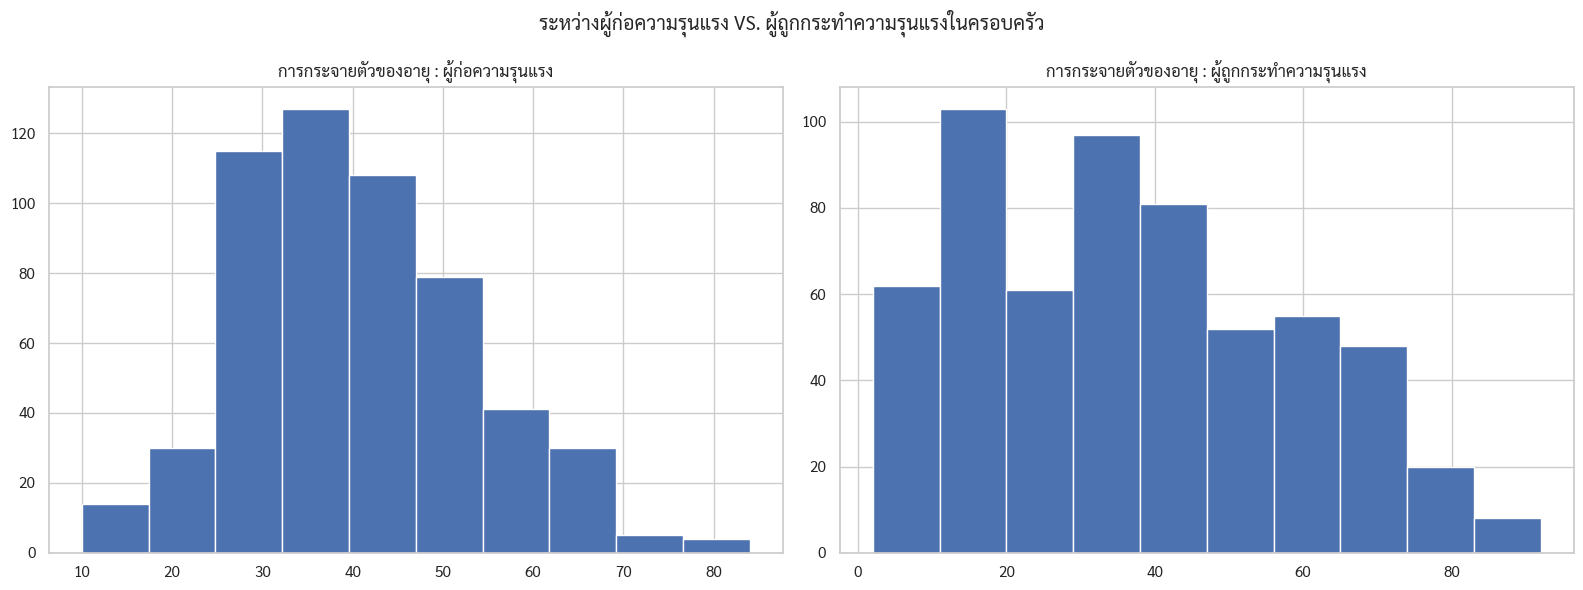

In [ ]:
## ดูการกระจายตัวอายุของทั้งสองกลุ่ม (ผู้ก่อความรุนแรงและผู้ถูกกระทำความรุนแรง)
fig, axes = plt.subplots(1, 2, figsize=(16, 6)) ## method สำหรับสร้างสองกราฟอยู่หน้าเดียวกัน
plt.suptitle('ระหว่างผู้ก่อความรุนแรง VS. ผู้ถูกกระทำความรุนแรงในครอบครัว', fontsize = 14, fontweight = 'bold') ## ชื่อ title ภาพรวมใหญ่ของทั้งสองกราฟ


## กราฟข้อมูลกระทำความรุนแรง
axes[0].hist(x = two_dvpd_df['age']) ## สร้างกราฟ Histogram เพื่อดูการกระจายตัวของข้อมูล
axes[0].set_title('การกระจายตัวของอายุ : ผู้ก่อความรุนแรง')

## กราฟข้อมูลผู้ถูกกระทำความความรุนแรง
axes[1].hist(x = three_dvvd_df['age'])
axes[1].set_title('การกระจายตัวของอายุ : ผู้ถูกกระทำความรุนแรง')

plt.tight_layout()
plt.show()

## การวิเคราะห์การกระจายตัวของอายุระหว่างผู้ก่อความรุนแรง VS. ผู้ถูกกระทำความรุนแรงในครอบครัว

**ผู้ก่อความรุนแรง : กลุ่มที่มีอายุเฉพาะเจาะจง**
> ลองมองภาพนี้ครับ ถ้าเราเอาคนที่ก่อความรุนแรงทั้งหมดมายืนเรียงกันตามอายุ แล้วนับว่าแต่ละช่วงอายุมีกี่คน เราจะเห็นว่าคนส่วนใหญ่กองรวมกันอยู่ที่ช่วง 30–40 ปี ราวกับเป็นยอดเขาที่สูงชันและแหลมคม แล้วก็ค่อย ๆ ลาดลงทั้งสองข้าง
>
> ก่อนอายุ 20 ปีนั้นมีผู้กระทำอยู่ราว 13–14 คน คนกลุ่มนี้มีอยู่จริง แต่ยังน้อยกว่าคนกลุ่มอื่น และตัวเลขนี้ไม่ควรมองข้ามเด็ดขาด เพราะกลุ่มวัยรุ่นถึงผู้ใหญ่ตอนต้นมักมีปัจจัยเสี่ยงด้านยาเสพติดบวกกับความไม่พร้อมการเลี้ยงดูบุตรเป็นแรงขับเคลื่อน และหลังอายุ 60 ปีจำนวนก็ลดลงชัดเจน
>
> สิ่งที่กราฟ Histogram นี้กำลังบอกเรา คือ ผู้กระทำความรุนแรงสามารถพบได้ทุกช่วงอายุ แต่ความเสี่ยงสูงสุดกระจุกตัวอยู่ช่วงวัยทำงานตอนกลางเสียเป็นส่วนใหญ่ มันเป็นช่วงชีวิตที่ต้องแบกรับความรับผิดชอบมากที่สุดไม่ว่าจะเป็นทั้งเรื่องงาน หนี้สิน พ่อแม่ หรือการเลี้ยงลูก ซึ่งสอดคล้องกับงานวิจัยงานบทความบ่งชี้ว่า ความเครียดทางเศรษฐกิจหรือปัญหาปากท้องเป็นตัวจุดชนวนสำคัญของความรุนแรงของหลาย ๆ ครอบครัว

**ผู้ถูกกระทำความรุนแรง : กลุ่มที่มีอายุเฉพาะเจาะจง**
> ทีนี้ลองทำแบบเดียวกันกับฝั่งเหยื่อ คราวนี้ภาพที่เห็นต่างกันอย่างสิ้นเชิง แทนที่จะเห็นยอดเขาแหลมอยู่ตรงกลาง กราฟฝั่งนี้กลับแบนและกว้าง กระจายออกเกือบทุกช่วงอายุ และที่สำคัญที่สุด คือ กราฟเริ่มต้นที่อายุ 0 นั้นหมายความว่ามีเด็กทารกและเด็กเล็กถูกทำร้ายร่างกายด้วยเช่นกัน
>
> นอกจากนั้นยังมีสิ่งที่น่าสนใจอีกอย่าง คือ กราฟที่มียอดนูนขึ้นมาสองจุดตั้งแต่ช่วง 15–20 ปี และช่วง 30–35 ปี เหมือนภูเขาสองลูกที่อยู่ติดกัน สิ่งนี้กำลังบอกพวกเราว่าน่าจะมีเหยื่อ สองกลุ่มใหญ่ที่ซ่อนอยู่ที่ข้อมูล กลุ่มแรกเป็นเด็กและวัยรุ่นที่ถูกทำร้ายด้วยฐานะของการเป็นลูก และกลุ่มที่สองคือผู้หญิงวัยทำงานที่ถูกทำร้ายด้วยฐานะของการเป็นภรรยาหรือแฟน

**เมื่อมองทั้งสองกราฟพร้อมกัน**
> ความแตกต่างที่ชัดเจนที่สุดระหว่างสองกราฟนี้จะเป็นเรื่องของ "ความกว้าง" ผู้ก่อความรุนแรงนั้นกระจุกตัวอยู่ที่ช่วงอายุแคบ ๆ แต่เหยื่อกระจายกว้างตั้งแต่แรกเกิดจนถึงอายุ 80 กว่าปี
>
>สมมติว่าบ้านหลังหนึ่งมีพ่ออายุ 38 ปีที่มีปัญหาเรื่องสารเสพติดและความเครียดทางการเงิน ผู้ที่ตกอยู่ในความเสี่ยงบ้านหลังนั้นอาจจะเป็นทั้งลูกอายุ 5 ขวบ ภรรยาอายุ 32 ปี จนถึงแม่ยายอายุ 65 ปีที่อาศัยอยู่ด้วยกัน นั่นคือเหตุผลที่กราฟฝั่งเหยื่อถึงกว้างขนาดนั้น เพราะผู้กระทำคนเดียวสามารถทำร้ายสมาชิกครอบครัวทุกคน
>
> ถ้าพวกเราอยากป้องกันความรุนแรงที่เกิดขึ้นของแต่ละครอบครัว เราไม่สามารถมองแค่ว่า "ใครเป็นเหยื่อของใคร" เพราะทุกคนที่บ้านอาจเป็นเหยื่อกันได้หมดทั้งนั้น ดังนั้น พวกเราต้องโฟกัสที่การระบุและช่วยเหลือ ซึ่งกราฟกำลังบอกเราว่ามักอยู่ช่วงวัยทำงานตอนกลาง และมักเผชิญกับแรงกดดันหลายด้านพร้อมกัน

Text(0, 0.5, 'อายุ')

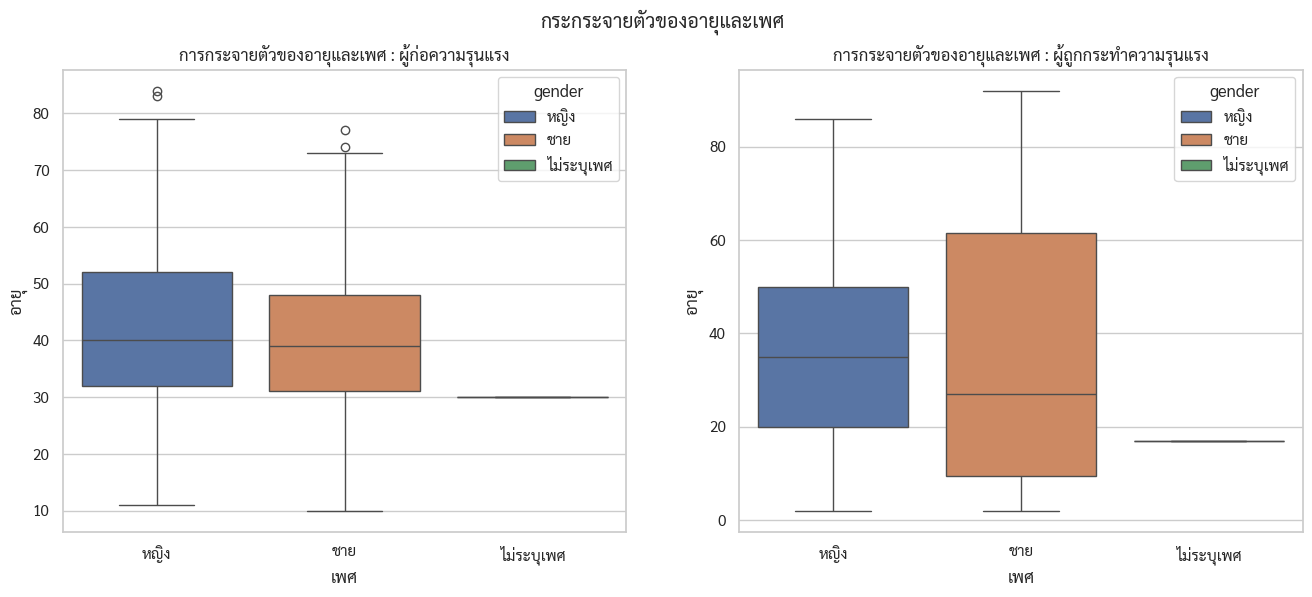

In [ ]:
## ดูการกระจายตัวของอายุเปรียบเทียบทั้งผู้กระทำความรุนแรงและผู้ถูกกระทำ
fig, axes = plt.subplots(1, 2, figsize=(16, 6)) ## method สำหรับสร้างสองกราฟอยู่หน้าเดียวกัน
fig.suptitle('กระกระจายตัวของอายุและเพศ', fontsize = 14, fontweight = 'bold') ## ชื่อ title ภาพรวมใหญ่ของทั้งสองกราฟ

## กราฟที่หนึ่ง - การกระจายตัวของอายุของผู้กระทำความรุนแรง
sns.boxplot(data = two_dvpd_df, x = 'gender', y = 'age', ax = axes[0], hue = 'gender', legend = True) ## สร้าง boxplot เพื่อดู Outlier & Percentage
axes[0].set_title('การกระจายตัวของอายุและเพศ : ผู้ก่อความรุนแรง') ## ชื่อ title ของแต่ละกราฟ
axes[0].set_xlabel('เพศ') ## ชื่อแกนนอน
axes[0].set_ylabel('อายุ') ## ชื่อแกนตั้ง

## กราฟที่สอง - การกระจายตัวของอายุของผู้ถูกกระทำความรุนแรง
sns.boxplot(data = three_dvvd_df, x = 'gender', y = 'age', ax = axes[1], hue = 'gender', legend = True)
axes[1].set_title('การกระจายตัวของอายุและเพศ : ผู้ถูกกระทำความรุนแรง')
axes[1].set_xlabel('เพศ')
axes[1].set_ylabel('อายุ')

## การวิเคราะห์การกระจายตัวของอายุและเพศระหว่างผู้ก่อความรุนแรง VS. ผู้ถูกกระทำความรุนแรงในครอบครัว

**ผู้ก่อความรุนแรง : แยกตามเพศและช่วงอายุ**
> สิ่งแรกที่เห็นทันที คือ กราฟสีน้ำเงิน (หญิง) และกราฟสีส้ม (ชาย) มีขนาดและตำแหน่งที่ใกล้เคียงกันมาก ค่ากลางของทั้งสองเพศอยู่ที่ประมาณ 40 ปีเท่ากัน และกล่องของทั้งคู่ก็มีความสูงพอ ๆ กัน ไม่ว่าคุณจะเป็นผู้กระทำความรุนแรงเพศหญิงหรือเพศชาย อายุที่พบบ่อยที่สุดมักจะอยู่ช่วงเดียวกัน คือ วัยทำงานตอนกลาง อย่างไรก็ตาม กราฟของหญิงสูงกว่าเล็กน้อย แปลว่าผู้ก่อความรุนแรงที่เป็นหญิงมีอายุกระจายกว้างกว่าเพศชายเล็กน้อยนั้นเอง

**ผู้ถูกกระทำความรุนแรง : แยกตามเพศและช่วงอายุ**
> ภาพที่เห็นฝั่งนี้ต่างออกกันอย่างสิ้นเชิง กราฟสีส้ม (ชาย) มีความสูงมากกว่ากราฟสีน้ำเงิน (หญิง) อย่างเห็นชัดเจน โดยค่ากลางของผู้ถูกกระทำที่เป็นชายอยู่ที่อายุประมาณ 24 ปี ซึ่งต่ำกว่าผู้ถูกกระทำที่เป็นหญิงซึ่งอยู่ที่อายุประมาณ 35 ปี อีกทั้งกล่องสีส้มยังยืดขึ้นถึง 60 ปีด้วย
>
> กราฟสีส้ม (ช่วง) ที่กว้างและครอบคลุมช่วงอายุ 0–90 กว่าปีนั้นกำลังบ่งชี้ว่า ผู้ถูกกระทำที่เป็นชายมีทุกวัยตั้งแต่เด็กเล็กจนถึงผู้สูงอายุ ซึ่งน่าจะมาจากสองกลุ่มที่ซ่อนอยู่ที่ข้อมูล เช่น เด็กผู้ชายที่ถูกทำร้ายด้วยฐานะการเป็นลูก และผู้ชายสูงอายุที่ถูกทำร้ายด้วยฐานะการเป็นพ่อหรือพ่อตา ส่วนกราฟสีน้ำเงิน (หญิง) ที่แคบกว่าและมีค่ากลางที่อายุประมาณ 35 ปีบ่งชี้ว่า ผู้ถูกกระทำที่เป็นหญิงกระจุกตัวที่วัยทำงาน ซึ่งสอดคล้องกับข่าวประจำวันที่มักบอกว่า เหยื่อหลัก คือ ภรรยาหรือคู่สมรสวัยทำงาน

**เมื่อมองทั้งสองกราฟพร้อมกัน**
> ความแตกต่างที่ชัดที่สุด คือ ฝั่งผู้ก่อความรุนแรงทั้งสองเพศมีขนาดกราฟใกล้เคียงกัน แต่ฝั่งผู้ถูกกระทำกราฟของสองเพศกลับต่างกันค่อนข้างมาก ทั้งขนาดและตำแหน่ง นั่นบอกว่า เพศมีผลต่อการตกเป็นเหยื่อมากกว่าที่มีผลต่อ "ใครจะเป็นคนก่อความรุนแรง"

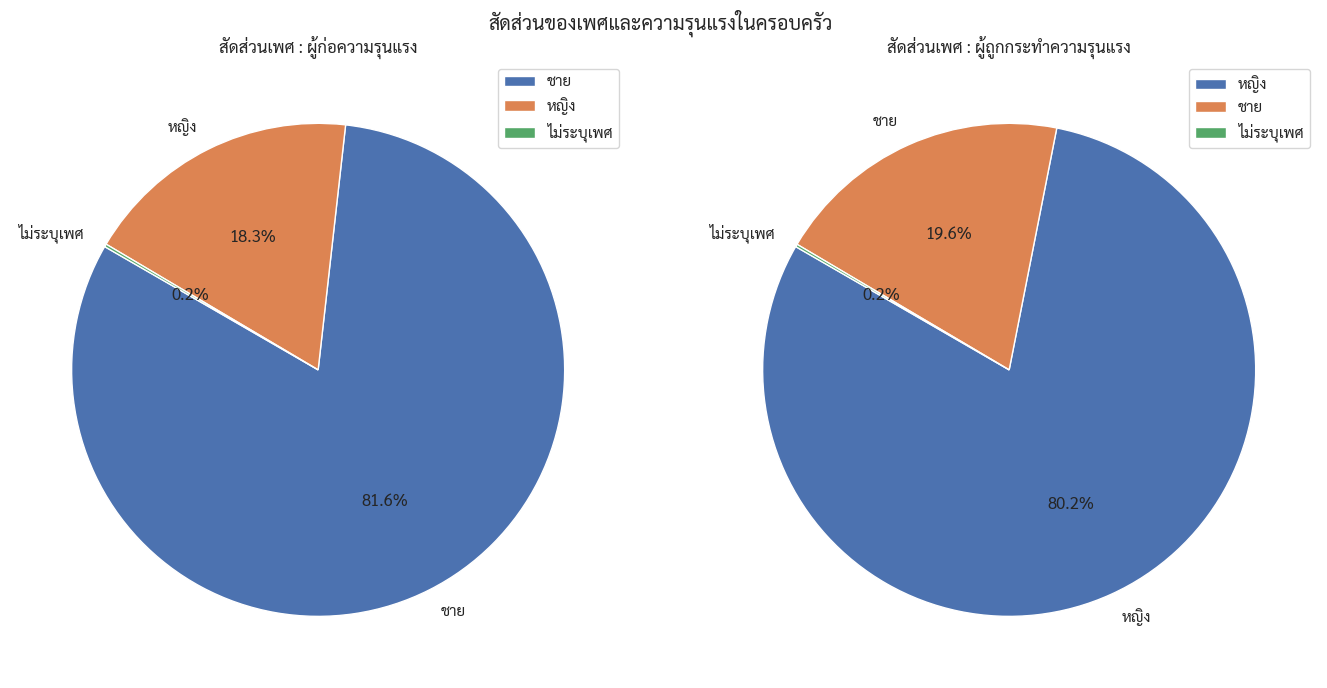

In [ ]:
## สร้าง pie chart เพื่อเปรียบเทียบสัดส่วนของเพศทั้งกลุ่มผู้กระทำความรุนแรงและผู้ถูกกระทำ
fig, axes = plt.subplots(1, 2, figsize = (14, 7))
fig.suptitle('สัดส่วนของเพศและความรุนแรงในครอบครัว', fontsize = 14, fontweight = 'bold')

two_dvpd_gender_df = two_dvpd_df['gender'].value_counts() ## เอาเฉพาะเพศมาสร้างเป็นกราฟ
three_dvvd_gender_df = three_dvvd_df['gender'].value_counts() ## เอาเฉพาะเพศมาสร้างเป็นกราฟ

## กราฟข้อมูลผู้ก่อความรุนแรง
axes[0].pie(x = two_dvpd_gender_df, labels = two_dvpd_gender_df.index, autopct = '%1.1f%%', startangle = 150)
axes[0].set_title('สัดส่วนเพศ : ผู้ก่อความรุนแรง')
axes[0].legend(loc = 'upper right') ## method สำหรับแสดง legend มุมขวาบน

## กราฟข้อมูลผู้ถูกกระทำความความรุนแรง
axes[1].pie(x = three_dvvd_gender_df, labels = three_dvvd_gender_df.index, autopct = '%1.1f%%', startangle = 150)
axes[1].set_title('สัดส่วนเพศ : ผู้ถูกกระทำความรุนแรง')
axes[1].legend(loc = 'upper right')

plt.tight_layout()
plt.show()

## การวิเคราะห์สัดส่วนเพศและความรุนแรงในครอบครัว

**ผู้ก่อความรุนแรง : แยกตามเพศ**
> ภาพแรกที่เห็น คือ วงกลมนี้ถูกครอบครองด้วยสีน้ำเงินเกือบทั้งหมด ตัวเลขบอกว่าผู้กระทำที่เป็นผู้ชายมีถึง 81.6% ขณะที่ผู้หญิงมีเพียง 18.3% หรือพูดง่าย ๆ ว่าผู้กระทำทุก 5 คน จะเป็นผู้ชาย 4 คนและผู้หญิง 1 คน ซึ่งตัวเลขนี้สอดคล้องกับที่ว่าความรุนแรงในครอบครัวมีรากฐานมาจากค่านิยมชายเป็นใหญ่และการใช้อำนาจเหนือคนในครอบครัว

**ผู้ถูกกระทำความรุนแรง : แยกตามเพศ**
> ตัวเลขออกมาคล้ายกันอย่างน่าประหลาดใจ เพราะผู้ถูกกระทำที่เป็นผู้หญิงถึง 80.2% และผู้ชายมี 19.6% ซึ่งแทบจะตรงกันข้ามกับกราฟฝั่งซ้ายเลย

**เมื่อมองทั้งสองกราฟพร้อมกัน**
> หลายคนอาจจะสรุปทันทีว่า "ผู้ชายทำร้ายผู้หญิง" แต่ความจริงซับซ้อนกว่านั้น เพราะจากกราฟที่ดูก่อนหน้า พวกเราจะเห็นแล้วว่าผู้ถูกกระทำความรุนแรงที่เป็นผู้ชายมีสัดส่วน 19.6% นั้นมีช่วงอายุกระจายกว้างมาก ตั้งแต่เด็กเล็กจนถึงผู้สูงอายุ ซึ่งน่าจะหมายความว่า ผู้ชายที่ตกเป็นเหยื่อส่วนใหญ่ คือ เด็กผู้ชายในบ้าน ไม่ใช่ผู้ชายวัยผู้ใหญ่ที่ถูกทำร้ายโดยผู้หญิง
>
> ถ้าหากกลับมามองฝั่งคนกระทำที่เป็นผู้หญิงมีสัดส่วนถึง 18.3% ก็น่าตั้งคำถามต่อว่า ผู้หญิงเหล่านี้ก่อความรุนแรงบริบทไหน เพราะหลายบทความก็มักจะบอกว่า ผู้หญิงที่กลายเป็นผู้ก่อความรุนแรงมักมีประวัติการถูกกระทำมาก่อน หรือเป็นปฏิกิริยาตอบโต้จากความกดดันสะสม ซึ่งเป็นคนละบริบทกับผู้ชายที่ก่อความรุนแรงเพื่อแสดงอำนาจ

**เมื่อมองทั้งสองกราฟพร้อมกัน**
> สรุปกราฟนี้แสดงความรุนแรงในครอบครัวมีมิติของเพศที่ไม่เท่ากัน แต่อย่าอ่านแค่ตัวเลขแบบไม่คิดถึงบริบทอย่างอื่นเลย เพราะตัวเลขที่หน้าตาคล้ายกันอาจซ่อนเรื่องราวที่ต่างกันอย่างสิ้นเชิง

In [ ]:
## ตรวจสอบข้อมูลช่วงอายุของผู้ก่อความรุนแรงแ เพื่อรีเข็ก value ใช้สำหรับการจัดเรียงลำดับการแสดงกราฟ
two_dvpd_df['age_range'].unique().tolist()

['วัยสูงอายุ 60 ปีขึ้นไป',
 'วัยผู้ใหญ่ตอนต้น 19 - 35 ปี',
 'วัยกลางคน 36 - 59 ปี',
 'วัยรุ่น 13 - 18 ปี',
 'วัยเด็กตอนกลาง 7 - 12 ปี']

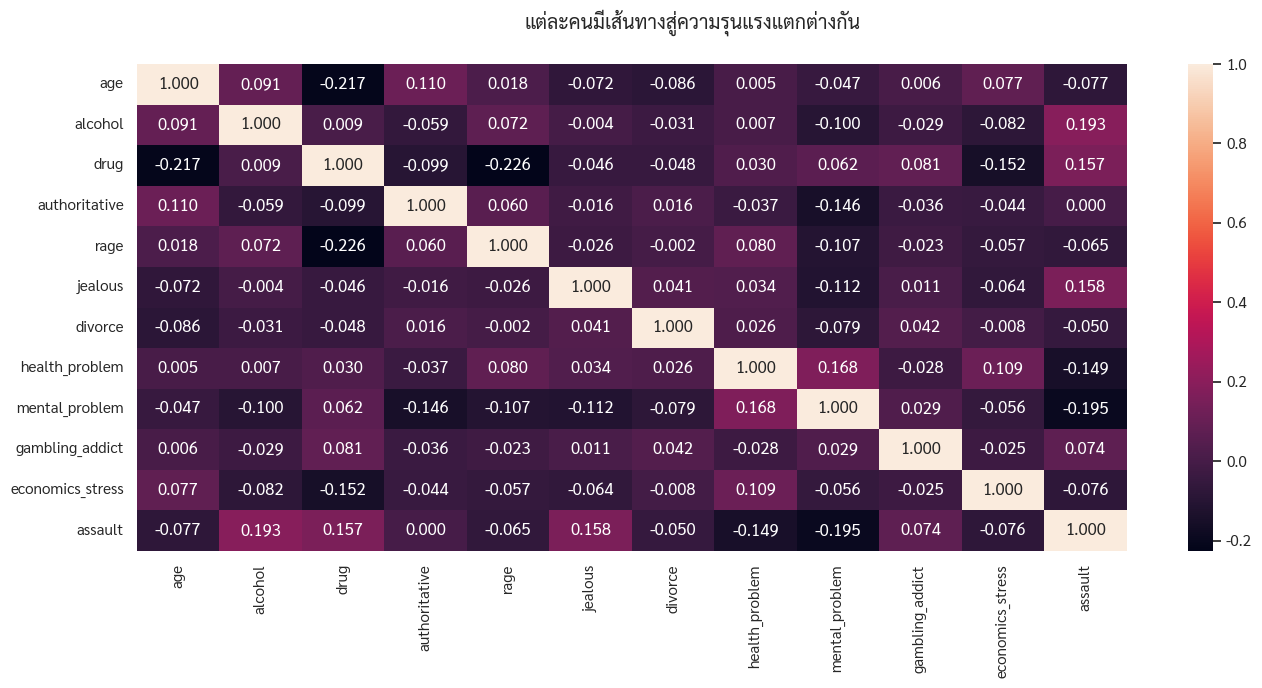

In [ ]:
## สร้างกราฟ heatmap หาความสัมพันพันธ์ของแต่ละตัวแปรสำหรับผู้ที่ก่อความรุนแรง
plt.figure(figsize = (14, 7))
plt.suptitle('แต่ละคนมีเส้นทางสู่ความรุนแรงแตกต่างกัน', fontsize = 14, fontweight = 'bold')

sns.heatmap(two_dvpd_df.corr(numeric_only = True), annot = True, fmt=".3f") ## สร้างเป็น heatmap เพื่อหาความสัมพันธ์ระหว่างตัวแปร

plt.tight_layout()
plt.show()

## แต่ละคนมีเส้นทางสู่ความรุนแรงที่ต่างกัน

**สิ่งที่น่าสนใจ**

> ปัจจัยเสี่ยงแต่ละตัวของชุดข้อมูลนี้ทำงานค่อนข้างอิสระต่อกัน ผู้กระทำคนหนึ่งอาจจะมีแค่ปัจจัยเดียว เช่น ดื่มแอลกอฮอล์ แต่ไม่มีปัญหาการพนัน ขณะที่อีกคนอาจจะติดยาเสพติด แต่ไม่มีความหึงหวง ซึ่งสอดคล้องกับที่ข่าวประจำวันมักบอกว่า ความรุนแรงสามารถเกิดจากหลายปัจจัย ก่อนจะวิเคราะห์ข้อมูล เราอยากอธิบายนิยามของ assault เสียก่อน
>
> ทุกคนอาจจะเข้าใจนิยามผิดกันหมด ถ้าหาก assault เท่ากับ 1 (ชาย) และ assault เท่ากับ 0 (หญิง) แปลว่า assault กราฟนี้ไม่ได้แปลว่า "การทำร้ายร่างกาย" แต่คือ "เพศ" ของผู้ก่อความรุนแรง ดังนั้น ทุกค่า correlation ที่ assault เกี่ยวข้องด้วยจึงต้องอ่านใหม่ว่า "ปัจจัยนี้พบที่เพศชายมากกว่าหรือน้อยกว่าเพศหญิงแค่ไหนกันต่างหาก"
>
> - แอลกอฮอล์ & เพศ (0.193) | ยาเสพติด & เพศ (0.157) บงชี้ว่าผู้กระทำที่เป็นผู้ชายมีแนวโน้มดื่มแอลกอฮอล์และยาเสพติดมากกว่าผู้หญิง ซึ่งสอดคล้องกับสัดส่วน 81.6% ที่เห็นที่พายกราฟก่อนหน้า
>
> - ปัญหาจิตใจ & เพศ (-0.195) บ่งชี้ตรงกันข้ามว่าปัญหาสุขภาพจิตพบผู้กระทำที่เป็นผู้หญิงมากกว่าผู้ชายสอดคล้องกับที่บทความหลายชิ้นอธิบายถึงผู้หญิงที่กลายเป็นผู้ก่อความรุนแรงมักมีพื้นหลังของการถูกกระทำมาก่อนและมีภาวะทางจิตใจที่ซับซ้อนกว่า
>
> - ความหึงหวง & เพศ (0.158) บ่งชี้ว่าความหึงหวงเป็นปัจจัยที่พบผู้กระทำที่เป็นผู้ชายมากกว่าผู้หญิง ซึ่งก็ตรงกับที่งานวิจัยบอกว่าผู้ชายมีแนวโน้มแปลงความหึงหวงเป็นความรุนแรงทางกายได้มากกว่า
>
> - ปัญหาสุขภาพ & ปัญหาจิตใจ (0.168) คู่ที่มีความสัมพันธ์สูงสุด แม้จะยังอ่อนอยู่ แต่ข้อมูลกำลังบอกว่าผู้ก่อความรุนแรงที่มีปัญหาสุขภาพกาย มักมีปัญหาสุขภาพจิตควบคู่ด้วย เพราะความเจ็บป่วยทางกายที่เรื้อรังมักนำมาสู่ความเครียดและภาวะซึมเศร้า
> - ยาเสพติด & อายุ (-0.217) | ยาเสพติด & ความโกรธ (-0.226) คู่ที่มีค่าลบที่เด่นที่สุด หมายถึง ยิ่งอายุมาก ยิ่งติดยาเสพติดน้อยลงและคนที่ใช้ยาเสพติด มักไม่ถูกบันทึกว่ามีอารมณ์โกรธรุนแรงร่วมด้วย ดังนั้น ยาเสพติดและความโกรธอาจเป็นสองเส้นทางที่นำมาสู่ความรุนแรงต่างกันไม่จำเป็นต้องเกิดพร้อมกันเสมอ

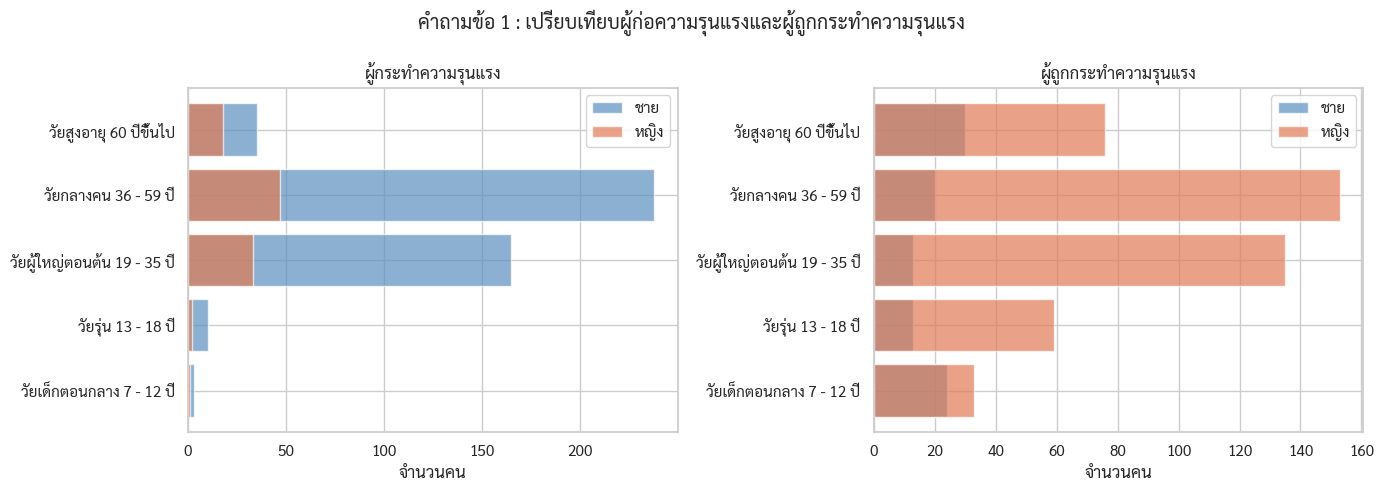

In [ ]:
## ตอบคำถามข้อที่หนึ่ง
age_range = ['วัยเด็กตอนกลาง 7 - 12 ปี',
            'วัยรุ่น 13 - 18 ปี',
            'วัยผู้ใหญ่ตอนต้น 19 - 35 ปี',
            'วัยกลางคน 36 - 59 ปี',
            'วัยสูงอายุ 60 ปีขึ้นไป']

fig, axes = plt.subplots(1, 2, figsize = (14, 5))
fig.suptitle('คำถามข้อ 1 : เปรียบเทียบผู้ก่อความรุนแรงและผู้ถูกกระทำความรุนแรง', fontsize = 14, fontweight = 'bold')

for ax, df, title in zip(axes, [two_dvpd_df, three_dvvd_df], ['ผู้กระทำความรุนแรง', 'ผู้ถูกกระทำความรุนแรง']):
  for gender, color in [('ชาย', '#5A8FBF'), ('หญิง', '#E07B54')]:
    sub = df[df['gender'] == gender]
    counts = sub['age_range'].value_counts().reindex(age_range, fill_value = 0)
    ax.barh(age_range, counts, color = color, label = gender, alpha = 0.7) ## สร้างกราฟแนวนอน

  ax.set_title(title, fontsize = 12)
  ax.set_xlabel('จำนวนคน')
  ax.legend() # เพิ่มคำสั่งเรียกแสดง legend ตรงนี้

plt.tight_layout()
plt.show()

## ภาพรวมความเสี่ยงจากทั้งสองบทบาท

**ผู้ก่อความรุนแรง : กระจุกตัวชัดเจน**

> แท่งสีน้ำเงิน (ชาย) กลุ่มวัยกลางคนอายุ 36–59 ปี ยาวออกมาอย่างโดดเด่นเกินกว่ากลุ่มอื่นประมาณ 230 กว่าคน ตามมาด้วยกลุ่มวัยผู้ใหญ่ตอนต้นอายุ 19–35 ปีที่ประมาณ 155 คน นั่นหมายความว่า ผู้ก่อความรุนแรงกระจุกตัวอยู่ช่วงวัยทำงานเกือบทั้งหมด และผู้ชายครองสัดส่วนหลักทุกกลุ่ม
>
> สิ่งที่น่าสังเกต คือ ผู้ก่อความรุนแรงที่เป็นผู้หญิง แม้จะมีน้อยกว่าแต่ก็ปรากฏอยู่ทุกช่วงอายุเช่นกัน โดยเฉพาะกลุ่มวัยกลางคนที่มีผู้หญิงประมาณ 40 คน ซึ่งสอดคล้องกับที่วิเคราะห์จาก Heatmap ก่อนหน้าว่า ผู้ก่อความรุนแรงที่เป็นผู้หญิงมักมีปัญหาสุขภาพจิตเป็นปัจจัยร่วม ไม่ใช่การใช้อำนาจแบบเดียวกับผู้ชาย

**ผู้ถูกกระทำความรุนแรง : กระจุกตัวชัดเจน**
> ฝั่งนี้เล่าเรื่องที่ต่างกันสิ้นเชิง กลุ่มที่มีจำนวนมากที่สุด คือ วัยกลางคนอายุ 36–59 ปี และ วัยผู้ใหญ่ตอนต้นอายุ 19–35 ปี ซึ่งมีจำนวนใกล้เคียงกันที่ประมาณ 140–150 คน และแท่งสีส้ม (หญิง) ยาวกว่าในเกือบทุกกลุ่มอายุ
>
> แต่จุดที่ต่างจากฝั่งซ้ายอย่างชัดเจนที่สุด คือ วัยรุ่นอายุ 13–18 ปี และวัยเด็กตอนกลางอายุ 7–12 ปี มีจำนวนผู้ถูกกระทำที่ไม่น้อยเลย ขณะที่ฝั่งผู้ก่อความรุนแรงแทบไม่มีตัวเลขอยู่ช่วงอายุเหล่านี้เลย สิ่งนี้ยืนยันสมมติฐานที่ตั้งตั้งแต่ตอนวิเคราะห์ Histogram เกี่ยวกับเด็กที่บ้านตกเป็นเหยื่อ โดยที่ตัวเองไม่มีส่วนเกี่ยวข้องฐานะผู้ก่อเหตุเลย

**ตอบคำถามข้อ 1 : ใครเสี่ยงที่สุดในแต่ละบทบาท?**
> บทบาท ผู้กระทำ กลุ่มที่มีความเสี่ยงสูงที่สุด คือ ชายวัยกลางคนอายุ 36–59 ปี ซึ่งกระจุกตัวช่วงอายุแคบ ๆ และครองสัดส่วนถึง 81.6% ของผู้กระทำทั้งหมด จากข่าวหรือบทความอธิบายว่า กลุ่มนี้จะเป็นช่วงชีวิตที่แบกรับความเครียดทางเศรษฐกิจสูงสุด ทั้งหนี้สิน การดูแลพ่อแม่ และการเลี้ยงดูบุตร และความกดดันจากบทบาทหัวหน้าครอบครัวตามค่านิยมชายเป็นใหญ่
>
> บทบาท ผู้ถูกกระทำ คำตอบซับซ้อนกว่า คือ ไม่มีกลุ่มใดกลุ่มเดียวที่เสี่ยงที่สุด แต่ความเสี่ยงกระจายอยู่ทุกวัยและทั้งสองเพศ โดยผู้หญิงวัยทำงานเสี่ยงฐานะที่เป็นคู่สมรส เด็กและวัยรุ่นเสี่ยงฐานะที่เป็นบุตร และผู้สูงอายุก็ยังปรากฏที่ข้อมูลด้วย สิ่งนี้กำลังสะท้อนว่า ผู้ก่อเหตุคนเดียวสามารถสร้างความเสี่ยงแก่สมาชิกในบ้านทุกคน โดยไม่จำกัดเพศหรือวัย
>
> ดังนั้น ถ้าถามว่าควรเริ่มต้นป้องกันจากจุดไหนก่อน พวกเราควรโฟกัสที่ชายวัยกลางคนที่มีสัญญาณเสี่ยง เช่น การดื่มแอลกอฮอล์ ยาเสพติด หรือความเครียดทางการเงิน เพราะการแก้ไขที่ต้นเหตุคนเดียวนั้นสามารถปกป้องสมาชิกที่บ้านทุกคนพร้อมกัน

In [ ]:
## ตรวจสอบข้อมูลภูมิภาค เพื่อรีเข็ก value ใช้สำหรับการจัดเรียงแกนนอนหรือแกนตั้งของกราฟ
problem_df['regional'].unique().tolist()

['ภาคกลาง', 'ภาคตะวันออกเฉียงเหนือ', 'ภาคเหนือ', 'ภาคใต้']

In [ ]:
## ตรวจสอบข้อมูลจังหวัด เพื่อรีเข็ก value ใช้สำหรับการจัดเรียงแกนนอนหรือแกนตั้งของกราฟ
problem_df['province'].unique()

array(['กรุงเทพมหานคร', 'กาญจนบุรี', 'จันทบุรี', 'ฉะเชิงเทรา', 'ชลบุรี',
       'ชัยนาท', 'ตราด', 'นครนายก', 'นนทบุรี', 'ปทุมธานี',
       'ประจวบคีรีขันธ์', 'ปราจีนบุรี', 'พระนครศรีอยุธยา', 'ระยอง',
       'ราชบุรี', 'ลพบุรี', 'สมุทรปราการ', 'สมุทรสงคราม', 'สมุทรสาคร',
       'สระบุรี', 'สระแก้ว', 'สิงห์บุรี', 'สุพรรณบุรี', 'อ่างทอง',
       'เพชรบุรี', 'กาฬสินธุ์', 'ขอนแก่น', 'ชัยภูมิ', 'นครพนม',
       'นครราชสีมา', 'บึงกาฬ', 'บุรีรัมย์', 'มหาสารคาม', 'มุกดาหาร',
       'ยโสธร', 'ร้อยเอ็ด', 'ศรีสะเกษ', 'สกลนคร', 'สุรินทร์', 'หนองคาย',
       'อุดรธานี', 'อุบลราชธานี', 'เลย', 'กำแพงเพชร', 'ตาก', 'นครสวรรค์',
       'น่าน', 'พะเยา', 'พิจิตร', 'พิษณุโลก', 'อุตรดิตถ์', 'อุทัยธานี',
       'เชียงราย', 'เพชรบูรณ์', 'แพร่', 'แม่ฮ่องสอน', 'กระบี่', 'ชุมพร',
       'นครศรีธรรมราช', 'นราธิวาส', 'ปัตตานี', 'พังงา', 'พัทลุง',
       'ภูเก็ต', 'ยะลา', 'ระนอง', 'สงขลา', 'สตูล', 'สุราษฎร์ธานี'],
      dtype=object)

In [ ]:
## ตรวจสอบระยะเวลาจากข้อมูลผู้แจ้งเหตุ เพื่อรีเข็ก value ใช้สำหรับการจัดเรียงแกนนอนหรือแกนตั้งของกราฟ
one_dvir_df['period'].unique().tolist()

['12:01 – 18:00', '18:01 – 00:00', '06:01 – 12:00', '00:01 – 06:00']

In [ ]:
## ตรวจสอบพื้นที่ที่มีการแจ้งเหตุจากข้อมูลผู้แจ้งเหตุ เพื่อรีเข็ก value ใช้สำหรับการจัดเรียงแกนนอนหรือแกนตั้งของกราฟ
one_dvir_df['locale'].unique().tolist()

['สถานที่ส่วนบุคคล', 'สถานที่ทำงาน', 'สถานที่สาธารณะ', 'สถานศึกษา']

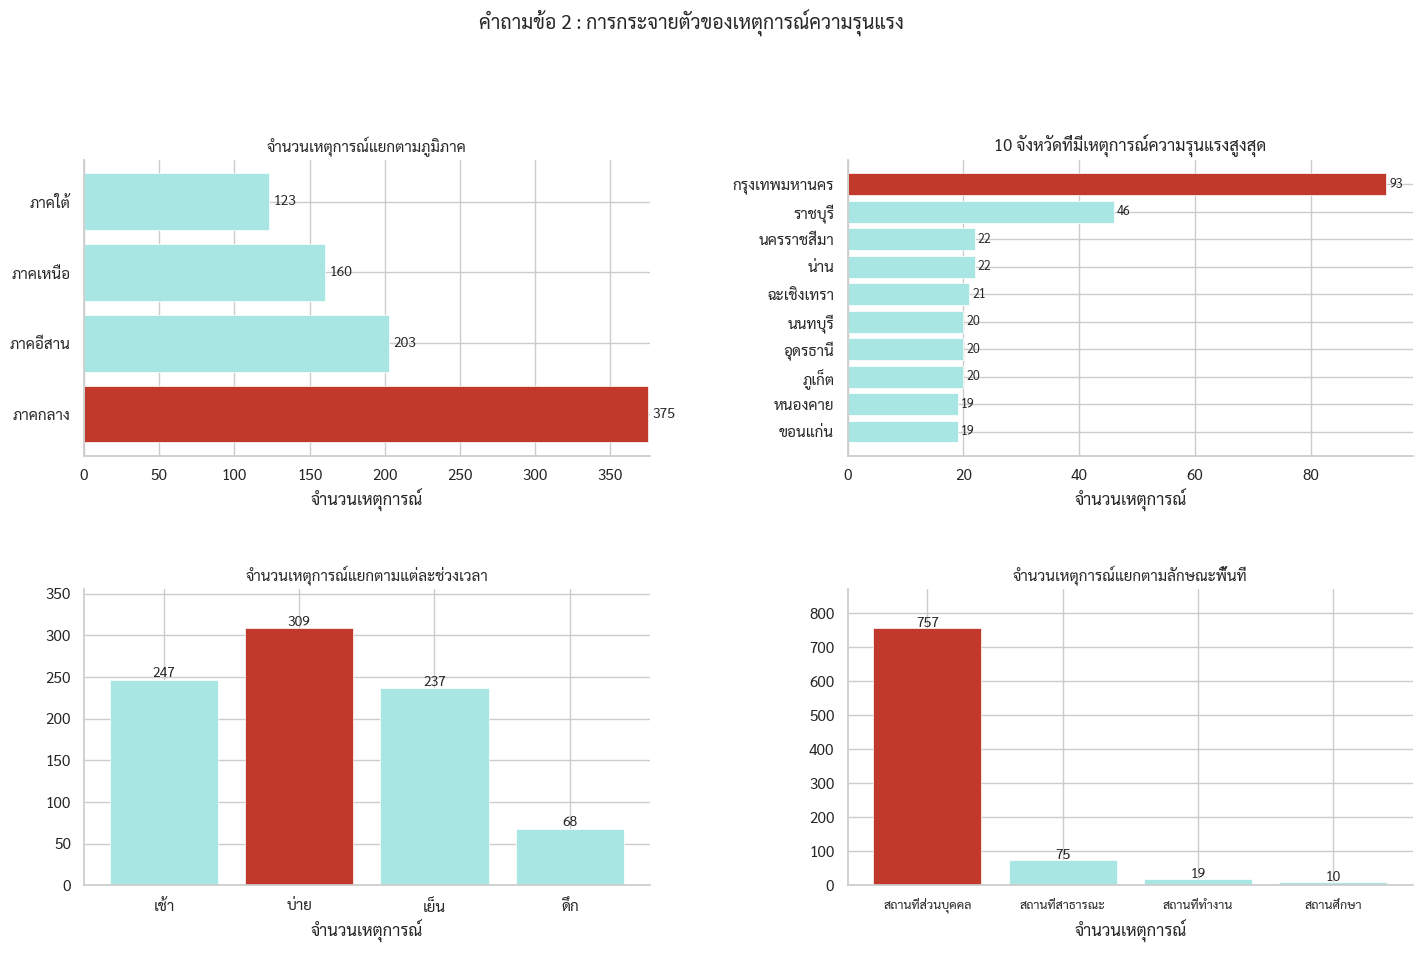

In [ ]:
## ตอบคำถามข้อที่สองแบ่งออกเป็น 4 ประเด็น

## layout
fig = plt.figure(figsize = (27, 15))
fig.suptitle('คำถามข้อ 2 : การกระจายตัวของเหตุการณ์ความรุนแรง', x = 0.35, fontweight = 'bold', y = 0.98, fontsize = 14)

gs = fig.add_gridspec(3, 3, hspace = 0.45, wspace = 0.35)
ax_1 = fig.add_subplot(gs[0, 0]) ## ภาค
ax_2 = fig.add_subplot(gs[0, 1]) ## จังหวัด
ax_3 = fig.add_subplot(gs[1, 0]) ## ช่วงเวลา
ax_4 = fig.add_subplot(gs[1, 1]) ## สถานที่

hotspot_color = '#C0392B' # สีแดงสำหรับจุดสูงสุด
normal_color  = '#A8E6E3' # สีเขียวอ่อนสำหรับจุดทั่วไป

bar_kw = dict(edgecolor = 'white', linewidth = 0.5)


## ตอบคำถามประเด็นที่หนึ่ง - เรื่องภูมิภาค
region_order = ['ภาคกลาง', 'ภาคตะวันออกเฉียงเหนือ', 'ภาคเหนือ', 'ภาคใต้']
region_labels = ['ภาคกลาง', 'ภาคอีสาน', 'ภาคเหนือ', 'ภาคใต้']
region_counts = one_dvir_df['regional'].value_counts().reindex(region_order, fill_value = 0)
color_r = [hotspot_color if v == region_counts.max() else normal_color for v in region_counts]

bars = ax_1.barh(region_labels, region_counts, color = color_r, **bar_kw)
for bar, val in zip(bars, region_counts.values):
  ax_1.text(val + 3, bar.get_y() + bar.get_height()/2, str(val),
            va = 'center', fontsize = 10) ## แสดง lebel ด้วยระยะห่างที่เหมาะสม

ax_1.set_title('จำนวนเหตุการณ์แยกตามภูมิภาค', fontsize = 11)
ax_1.set_xlabel('จำนวนเหตุการณ์')
ax_1.spines[['top', 'right']].set_visible(False)
ax_1.set_xlim(0, region_counts.max() + 1.15)


## ตอบคำถามประเด็นที่สอง - เรื่องพื้นที่แต่ละจังหวัด
## โฟกัสเฉพาะ 10 จังหวัดแรก เพราะกราฟมีพื้นที่จำกัด
top_prov = one_dvir_df['province'].value_counts().head(10)
color_p = [hotspot_color if v == top_prov.max() else normal_color for v in top_prov.values]

bars_2 = ax_2.barh(top_prov.index[::-1], top_prov.values[::-1], color = color_p[::-1], **bar_kw)
for bar, val in zip(bars_2, top_prov.values[::-1]):
  ax_2.text(val + 0.5, bar.get_y() + bar.get_height()/2, str(val),
            va = 'center', fontsize = 9)

ax_2.set_title('10 จังหวัดที่มีเหตุการณ์ความรุนแรงสูงสุด')
ax_2.set_xlabel('จำนวนเหตุการณ์')
ax_2.spines[['top', 'right']].set_visible(False)


## ตอบคำถามประเด็นที่สาม - เรื่องเวลา
period_order = ['06:01 – 12:00',  '12:01 – 18:00', '18:01 – 00:00', '00:01 – 06:00']
period_labels = ['เช้า', 'บ่าย', 'เย็น', 'ดึก']
period_counts = one_dvir_df['period'].value_counts().reindex(period_order, fill_value = 0)

color_t = [hotspot_color if v == period_counts.max() else normal_color for v in period_counts]
bars_3 = ax_3.bar(period_labels, period_counts, color = color_t, **bar_kw)
for bar, val in zip(bars_3, period_counts.values):
  ax_3.text(bar.get_x() + bar.get_width()/2, val + 3, str(val),
            ha = 'center', fontsize = 10)

ax_3.set_title('จำนวนเหตุการณ์แยกตามแต่ละช่วงเวลา', fontsize = 11)
ax_3.set_xlabel('จำนวนเหตุการณ์')
ax_3.spines[['top', 'right']].set_visible(False)
ax_3.set_ylim(0, period_counts.max() * 1.15)


## ตอบคำถามประเด็นที่สี่ - สถานที่
local_counts = one_dvir_df['locale'].value_counts()
color_l = [hotspot_color if v == local_counts.max() else normal_color for v in local_counts.values]

bars_4 = ax_4.bar(local_counts.index, local_counts.values, color = color_l, **bar_kw)
for bar, val in zip(bars_4, local_counts.values):
  ax_4.text(bar.get_x() + bar.get_width()/2, val + 3, str(val),
            ha = 'center', fontsize = 10)

ax_4.set_title('จำนวนเหตุการณ์แยกตามลักษณะพื้นที่', fontsize = 11)
ax_4.set_xlabel('จำนวนเหตุการณ์')
ax_4.spines[['top', 'right']].set_visible(False) ## ไม่ต้องแสดงกรอบ เพื่อความสวยงาม
ax_4.set_ylim(0, local_counts.max() * 1.15)
ax_4.tick_params(axis = 'x', labelsize = 9)


plt.tight_layout()
plt.show()

## ปัจจัยเร่งความรุนแรงครอบครัวคนไทย

**มิติพื้นที่ : กราฟซ้ายบน**

> ภาคกลางมีจำนวนเหตุการณ์สูงที่สุดอย่างท่วมท้นที่ 375 ครั้ง มากกว่าภาคอีสานที่อยู่อันดับสองถึงเกือบสองเท่า และกราฟจังหวัดบนขวายิ่งชัดขึ้นอีก เมื่อเห็นว่ากรุงเทพมหานครมีเหตุการณ์ถึง 93 ครั้ง ทิ้งห่างราชบุรีที่เป็นอันดับสองที่มีเหตุการณ์ถึง 46 ครั้ง
>
> ตัวเลขนี้ไม่ได้แปลว่าคนกรุงเทพรุนแรงกว่าคนภาคอื่น แต่ต้องอ่านควบคู่กับบทความหรือข่าวที่อธิบายว่า พื้นที่ที่มีความหนาแน่นของประชากรสูง มีการย้ายถิ่นฐานของแรงงาน และมีค่าครองชีพที่บีบคั้นจะมีอัตราการแจ้งเหตุสูงกว่าตามธรรมชาติ นอกจากนี้กรุงเทพยังมีระบบการแจ้งเหตุที่เข้าถึงง่ายกว่าพื้นที่ห่างไกล หมายความว่าตัวเลขพื้นที่ชนบทอาจจะต่ำกว่าความเป็นจริง

**มิติช่วงเวลา : กราฟล่างซ้าย**
> ช่วงบ่ายมีจำนวนเหตุการณ์สูงสุดถึง 309 ครั้ง ตามมาด้วยช่วงเช้า 247 ครั้ง และช่วงเย็น 237 ครั้ง ขณะที่ช่วงดึกมีน้อยที่สุดที่ 68 ครั้ง
>
> สิ่งที่น่าคิด คือ หลายคนอาจจะจินตนาการว่า ความรุนแรงของครอบครัวมักเกิดตอนดึกหลังจากดื่มเหล้ากลับบ้าน แต่ข้อมูลบอกตรงกันข้าม คือ  การที่ช่วงบ่ายมีเหตุการณ์มากที่สุดอาจจะสามารถอธิบายว่า มันเป็นช่วงที่สมาชิกครอบครัวอยู่บ้านพร้อมกัน ความเครียดสะสมจากกิจกรรมตั้งแต่ช่วงเช้าถึงบ่ายยังไม่คลี่คลาย และแรงกดดันต่าง ๆ ปะทุขึ้นช่วงนี้พอดิบพอดี

**มิติสถานที่ : กราฟล่างขวา**
> สถานที่ส่วนบุคคล (บ้าน) มีจำนวนเหตุการณ์ถึง 757 ครั้ง ขณะที่สถานที่สาธารณะมีเพียง 75 ครั้ง สถานที่ทำงาน 19 ครั้ง และสถานศึกษา 10 ครั้ง นั่นแปลว่าเกือบ 88% ของเหตุการณ์ทั้งหมดเกิดขึ้นที่บ้านสอดคล้องกับที่ข่าวประจำวันหรือบทความอธิบายว่า บ้านเป็นพื้นที่ปิดที่ผู้ก่อความรุนแรงมีอำนาจเหนือสมาชิกทุกคน และเหยื่อมักไม่สามารถหลบหนีหรือขอความช่วยเหลือ

**ตอบคำถามข้อ 2: จุดวิกฤตคือที่ไหนและเมื่อไหร่?**
> เมื่อนำทั้งสี่กราฟมาผนวกกัน จุดวิกฤตที่ชัดเจนที่สุดของข้อมูลชุดนี้ คือ บ้านพักเขตภาคกลางและกรุงเทพมหานครช่วงเวลาบ่ายของวัน หมายความว่า ถ้าหากหน่วยงานที่เกี่ยวข้องต้องการจัดสรรทรัพยากรอย่างมีประสิทธิภาพ ควรโฟกัสการเฝ้าระวังพื้นที่ชุมชนเมืองหนาแน่นที่ภาคกลางเป็นลำดับแรก และควรมีระบบรับแจ้งเหตุและตอบสนองที่รวดเร็วช่วงบ่ายเป็นการเฉพาะ
>
> อย่างไรก็ตาม ตัวเลขที่กราฟ คือจำนวนที่ถูกรายงาน ไม่ใช่จำนวนที่เกิดขึ้นจริงทั้งหมด พื้นที่ที่มีการแจ้งเหตุน้อยอย่างภาคใต้หรือพื้นที่ชนบทห่างไกล อาจมีความรุนแรงเกิดขึ้นระดับที่ไม่ต่างกันมากนัก แต่เหยื่อเข้าไม่ถึงช่องทางการรายงาน ดังนั้น จุดวิกฤตจริง ๆ อาจกว้างกว่าที่กราฟแสดงออกมา

In [ ]:
problem_df.columns.tolist()

['regional',
 'province',
 'district',
 'sub_district',
 'gender',
 'age',
 'age_range',
 'relation',
 'marriage_registration',
 'alcohol',
 'drug',
 'authoritative',
 'rage',
 'jealous',
 'divorce',
 'health_problem',
 'mental_problem',
 'gambling_addict',
 'economics_stress',
 'role',
 'assault']

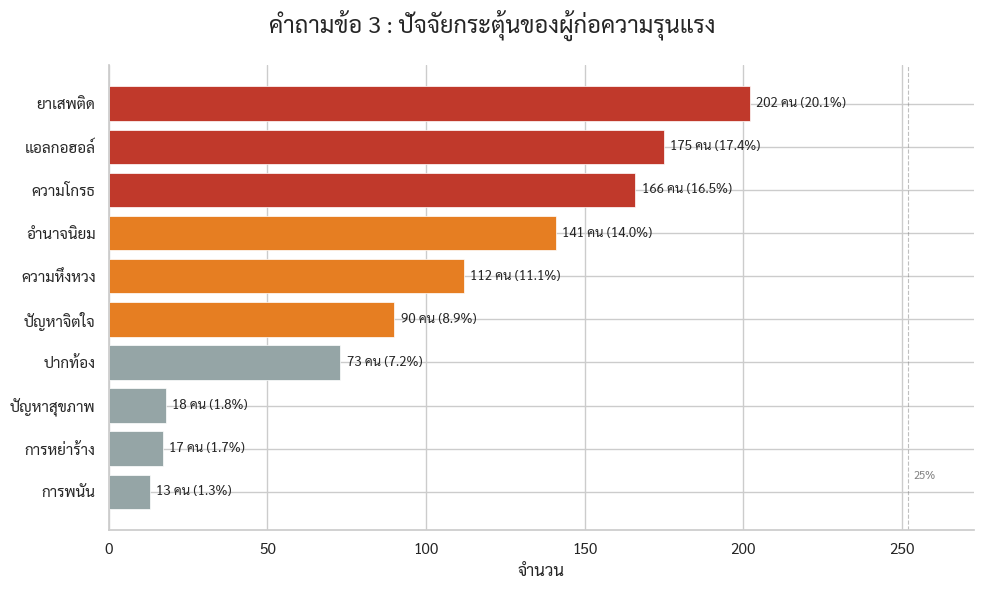

In [ ]:
## ตอบคำถามข้อที่สาม

bool_cols = [
              'alcohol', 'drug', 'authoritative', 'rage', 'jealous', 'divorce',
              'health_problem', 'mental_problem', 'gambling_addict', 'economics_stress'
            ]

labels_th = {
            'alcohol' : 'แอลกอฮอล์', 'drug' : 'ยาเสพติด', 'authoritative' : 'อำนาจนิยม',
             'rage' : 'ความโกรธ', 'jealous' : 'ความหึงหวง', 'divorce' : 'การหย่าร้าง',
             'health_problem' : 'ปัญหาสุขภาพ', 'mental_problem' : 'ปัญหาจิตใจ',
             'gambling_addict' : 'การพนัน', 'economics_stress' : 'ปากท้อง'
             }


for col in bool_cols:
  two_dvpd_df[col] = two_dvpd_df[col].map({True : 1, False : 0})

## คำนวณ %contribution
total = two_dvpd_df[bool_cols].sum().sum()
counts = two_dvpd_df[bool_cols].sum().rename(labels_th).sort_values()
pct = (counts / total * 100) ## ไม่น่าจะใช่


## เริ่มต้นสร้างกราฟกันเลย
fig, axes = plt.subplots(figsize = (10, 6))
fig.suptitle('คำถามข้อ 3 : ปัจจัยกระตุ้นของผู้ก่อความรุนแรง', fontsize = 17, fontweight = 'bold')

## สร้างลำดับชั้นของสี
colors = []
for i, v in enumerate(counts.values):
  if i >= 7:    colors.append('#C0392B') ## สามอันดับแรก
  elif i >= 4:  colors.append('#E67E22') ## อันดับกลาง
  else:         colors.append('#95A5A6') ## อันดับล่าง

## สร้างกราฟแนวนอน
bars = axes.barh(counts.index, counts.values, color = colors, edgecolor = 'white', linewidth = 0.5)


## สร้าง labels
for bar, val, p in zip(bars, counts.values, pct.values):
  axes.text(val + 2, bar.get_y() + bar.get_height()/2,
            f'{val} คน ({p:.1f}%)', va = 'center', fontsize = 9.5)


axes.set_xlabel('จำนวน')
axes.set_xlim(0, counts.max() * 1.35)
axes.spines[['top', 'right']].set_visible(False)
axes.axvline(x = total * 0.25, color = 'gray', linewidth = 0.8, linestyle = '--', alpha = 0.5)
axes.text(total * 0.25 + 2, 0.3, '25%', fontsize = 8, color = 'gray')

plt.tight_layout()
plt.show()

**กลุ่มแดง : สามปัจจัยที่ต้องแก้**
> ยาเสพติด (202 คน, 20.1%) ครองอันดับหนึ่งอย่างชัดเจน ตามมาด้วย แอลกอฮอล์ (175 คน, 17.4%) และความโกรธ (166 คน, 16.5%) รวมกันสามปัจจัยนี้คิดเป็นกว่า 54% ของปัจจัยเสี่ยงทั้งหมด และถ้าอ่านควบคู่กับข่าวประจำวันหรือบทความที่ศึกษามา จะพบว่า สามตัวนี้ไม่เคยทำงานแยกกัน
>
> ลองนึกภาพแบบนี้ ยาเสพติดแบบเมทแอมเฟตามีนกระตุ้นระบบประสาทอย่างรุนแรง และส่งผลเกิดอาการหวาดระแวงและอารมณ์แปรปรวน เมื่อใช้ร่วมกับแอลกอฮอล์ที่กดการทำงานของสมองส่วนหน้าซึ่งควบคุมการตัดสินใจ คือ ความโกรธที่ไม่มีสิ่งใดยับยั้งอีกแล้ว ดังนั้น สามปัจจัยนี้จึงเป็นเหมือนฟันเฟืองที่เชื่อมต่อกัน และไม่เคยแยกขาดจากกันเลย

**กลุ่มส้ม : ปัจจัยที่บอกถึงรูปแบบความสัมพันธ์**
> อำนาจนิยม (141 คน, 14.0%) และความหึงหวง (112 คน, 11.1%) เป็นกลุ่มรอง แต่ไม่ควรมองข้ามแม้แต่น้อย เพราะสองปัจจัยนี้บ่งบอกถึงลักษณะของความสัมพันธ์ที่มีความเสี่ยงเชิงโครงสร้าง หมายถึง ผู้ก่อความรุนที่ใช้ความรุนแรงเพื่อควบคุม ไม่ใช่เพราะสารเคมีจากสมองถูกรบกวน ซึ่งข่าวประจำวันหรือบทความ ระบุว่า คนกลุ่มนี้มักสัมพันธ์กับค่านิยมชายเป็นใหญ่และความกลัวการสูญเสียอำนาจในครอบครัว
>
> ส่วนปัญหาจิตใจ (90 คน, 8.9%) นั้นสอดคล้องกับที่เห็นที่ Heatmap ก่อนหน้าว่า ปัญหาจิตใจมีความสัมพันธ์กับเพศหญิงมากกว่าเพศชาย ซึ่งอาจหมายความว่าปัจจัยนี้มาจากบริบทที่ต่างออกกัน เช่น ผู้ก่อความรุนแรงเคยเป็นเหยื่อมาก่อน

**กลุ่มเทา : มีจำนวนน้อย แต่สูงเรื่องความเสี่ยง**
> ปากท้อง (73 คน, 7.2%) ถูกจัดอยู่กลุ่มเทา แต่มีนัยสำคัญมากเชิงนโยบาย เพราะความเครียดทางการเงินเป็นปัจจัยที่เชื่อมโยงกับเกือบทุกปัจจัยอื่น งานวิจัยระบุว่า ช่วงโควิด-19 ครอบครัวที่เผชิญความไม่มั่นคงทางการเงินมีการทะเลาะวิวาทเพิ่มขึ้นถึง 23% ส่วนปัญหาสุขภาพ การหย่าร้าง และการพนันพบน้อยที่สุด แต่ก็เป็นสัญญาณเตือนที่ไม่ควรละเลยระดับรายบุคคลเช่นกัน

**ตอบคำถามข้อ 3 : ควรเริ่มต้นจากปัจจัยใดก่อน?**
> ทิศทางแรก คือ การแก้ที่สารเสพติดและแอลกอฮอล์มีสัดส่วนสูงถึง 37.5% เพราะนี่คือปัจจัยที่ส่งผลต่อต่อสมองโดยตรง และนำมาสู่ความโกรธที่ควบคุมไม่ได้ การมีโปรแกรมบำบัดและการเข้าถึงการรักษาที่ง่ายขึ้นที่ชุมชนจึงเป็นมาตรการที่คุ้มค่าที่สุดของการลงทุนเพื่อลดความรุนแรง
>
> ทิศทางที่สอง คือ การแก้ที่ทัศนคติและความสัมพันธ์ โดยเฉพาะอำนาจนิยมและความหึงหวงที่รวมกันถึง 25.1% เพราะปัจจัยเหล่านี้ไม่สามารถแก้ด้วยยาหรือการบำบัด แต่ต้องเปลี่ยนแปลงทางทัศนคติและความเชื่อที่ฝังรากลึก มันอาจจะต้องอาศัยการทำงานระยะยาวผ่านการศึกษา
>
> กราฟนี้ไม่บอกแค่ว่า "อะไรเป็นสาเหตุ" แต่บอกด้วยว่า มาตรการป้องกันควรมีสองระดับ คือ การแก้ปัจจัยระยะสั้นของรายบุคคล และการเปลี่ยนแปลงทัศนคติระยะยาว เพราะถ้าแก้แค่ด้านเดียว ความรุนแรงก็ยังคงเกิดขึ้นจากอีกด้านที่เหลืออยู